<a href="https://colab.research.google.com/github/MarwaAyash/TB-project/blob/MarwaAyash/TB_projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split, GroupKFold, GroupShuffleSplit
from pandas.api.types import is_numeric_dtype, is_object_dtype
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import fbeta_score, roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
import xgboost as xgb


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_path = "/content/drive/MyDrive/solicited_combined_database.pkl"
data = pd.read_pickle(data_path)

print("Data loaded:", data.shape)
print("\nData overview:")
display(data.head())


print(f"Total unique participants: {data['participant'].nunique()}")
print(f"Total records: {len(data)}")
print(f"Average records per participant: {len(data) / data['participant'].nunique():.2f}")

Data loaded: (9772, 29)

Data overview:


,participant,sex,age,height,weight,reported_cough_dur,tb_prior,tb_prior_Pul,tb_prior_Extrapul,tb_prior_Unknown,...,Country,Numberofcoughsoundscollected,HIVstatus,Microbiologicreferencestandard,Sputumxpertreferencestandard,Xpertcombinedsemiquant,filename,sound_prediction_score,sample_rate,audio_signal
0,CODA_TB_0001,Male,27,173.3,63.0,30,No,No,No,No,...,UG,18,Negative,Negative,Negative,NaN,1645088710003-recording-1.wav,0.990254,44100,"[518, 408, 353, 359, 350, 374, 304, 336, 345, ..."
1,CODA_TB_0001,Male,27,173.3,63.0,30,No,No,No,No,...,UG,18,Negative,Negative,Negative,NaN,1645088760390-recording-1.wav,0.990272,44100,"[773, 773, 794, 808, 784, 753, 740, 744, 764, ..."
2,CODA_TB_0001,Male,27,173.3,63.0,30,No,No,No,No,...,UG,18,Negative,Negative,Negative,NaN,1645088760830-recording-1.wav,0.990112,44100,"[-54, -41, -20, -10, -19, -8, 8, 27, 37, 53, 3..."
3,CODA_TB_0001,Male,27,173.3,63.0,30,No,No,No,No,...,UG,18,Negative,Negative,Negative,NaN,1645088710843-recording-1.wav,0.990152,44100,"[-6, -36, -63, -71, -49, -14, -10, -9, -35, -2..."
4,CODA_TB_0001,Male,27,173.3,63.0,30,No,No,No,No,...,UG,18,Negative,Negative,Negative,NaN,1645088759950-recording-1.wav,0.990039,44100,"[72, 37, 22, 53, 92, 98, 61, 42, 64, 58, 40, 4..."


Total unique participants: 1082
Total records: 9772
Average records per participant: 9.03


In [ ]:
# Valeurs manquantes
missing_values = data.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
print("\nColonnes avec valeurs manquantes:")
print(missing_values)


Colonnes avec valeurs manquantes:
Xpertcombinedsemiquant            7110
HIVstatus                           25
height                              23
Microbiologicreferencestandard       4
dtype: int64


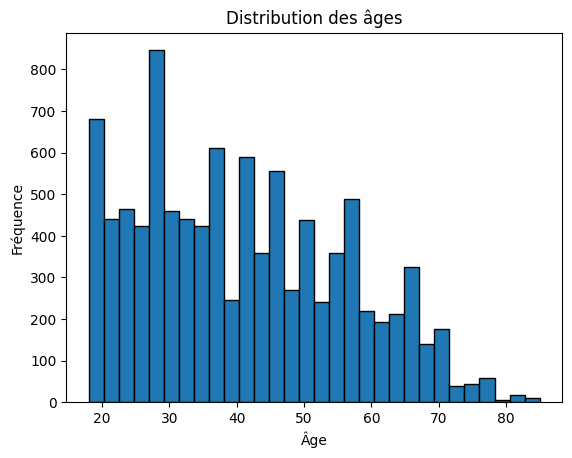

sex
Male      5023
Female    4749
Name: count, dtype: int64
Country
UG    2166
VN    1791
PH    1356
MG    1293
SA    1119
IN    1043
TZ    1004
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

# Histogramme des âges
plt.hist(data['age'], bins=30, edgecolor='black')
plt.title("Distribution des âges")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.show()

# Sexe
print(data['sex'].value_counts())

# Pays
print(data['Country'].value_counts().head(10))

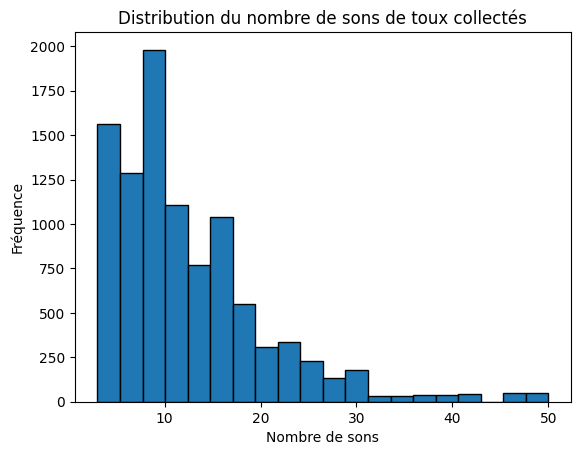

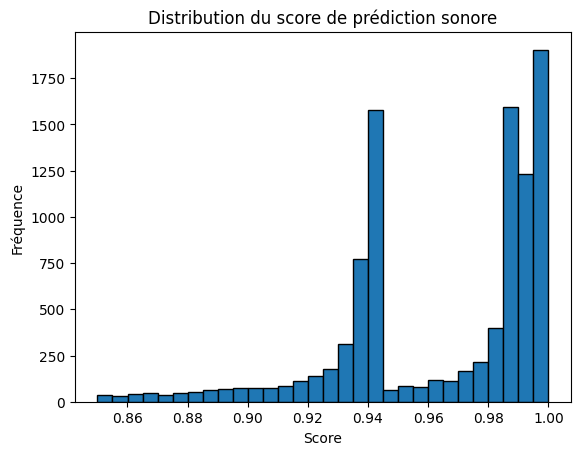

In [ ]:
plt.hist(data['Numberofcoughsoundscollected'], bins=20, edgecolor='black')
plt.title("Distribution du nombre de sons de toux collectés")
plt.xlabel("Nombre de sons")
plt.ylabel("Fréquence")
plt.show()

plt.hist(data['sound_prediction_score'], bins=30, edgecolor='black')
plt.title("Distribution du score de prédiction sonore")
plt.xlabel("Score")
plt.ylabel("Fréquence")
plt.show()


In [ ]:
# Features cliniques selon les spécifications du professeur
CLINICAL_FEATURES = [
    "age", "height", "weight", "BMI", "reported_cough_dur",
    "heart_rate", "temperature", "weight_loss", "smoke_lweek",
    "fever", "night_sweats",
]

# Cible
target_col = "tb_status"

# Colonnes à supprimer pour éviter les fuites
cols_to_drop = [
    "Microbiologicreferencestandard", "Sputumxpertreferencestandard",
    "sound_prediction_score", "Xpertcombinedsemiquant", "HIVstatus",
    "tb_prior", "tb_prior_Pul", "tb_prior_Extrapul", "tb_prior_Unknown",
    "filename", "type", "Country", "Numberofcoughsoundscollected"
]

data = data.drop(columns=[c for c in cols_to_drop if c in data.columns], errors="ignore")

# Supprimer les lignes sans target
data = data.dropna(subset=[target_col])

# Supprimer les doublons par participant
data = data.drop_duplicates(subset=["participant"])

print(f"\nShape après nettoyage: {data.shape}")


Shape après nettoyage: (1082, 16)


In [ ]:
def extract_robust_audio_features(audio_signal, sample_rate, n_mfcc=13):
   # conversion en float32
    try:
        y = np.asarray(audio_signal, dtype=np.float32)

        # Normalisation
        if np.max(np.abs(y)) > 0:
            y = y / np.max(np.abs(y))


        # Extraction des features
        mfccs = librosa.feature.mfcc(
            y=y, sr=sample_rate, n_mfcc=n_mfcc,
            n_fft=2048, hop_length=512, n_mels=40
        )

        # Éviter les features trop complexes qui peuvent causer l'overfitting
        mel_spectrogram = librosa.feature.melspectrogram(
            y=y, sr=sample_rate, n_mels=40
        )
        mel_log = librosa.power_to_db(mel_spectrogram)

        # Features spectrales simples
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sample_rate)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sample_rate)

        # Extraire les statistiques de base
        features = []

        for feature_matrix in [mfccs, mel_log, spectral_centroid, spectral_rolloff]:
            features.extend([
                np.mean(feature_matrix, axis=1),
                np.std(feature_matrix, axis=1),
                np.min(feature_matrix, axis=1),
                np.max(feature_matrix, axis=1)
            ])

        return np.concatenate(features)

    except Exception as e:
        print(f"Audio processing error: {e}")
        return np.zeros(13 * 4 + 40 * 4 + 1 * 4 + 1 * 4)

# Extraction des features audio

audio_features = []
for i, row in data.iterrows():
    if "audio_signal" in row and "sample_rate" in row:
        audio_features.append(extract_robust_audio_features(row["audio_signal"], row["sample_rate"]))
    else:
        audio_features.append(np.zeros(13 * 4 + 40 * 4 + 1 * 4 + 1 * 4))

# Créer les noms de colonnes
columns = []
feature_types = [('mfcc', 13), ('mel', 40), ('centroid', 1), ('rolloff', 1)]

for prefix, n_feat in feature_types:
    for stat in ["mean", "std", "min", "max"]:
        columns.extend([f"{prefix}{i}_{stat}" for i in range(n_feat)])

audio_df = pd.DataFrame(audio_features, columns=columns)
# Concaténation des MFCC avec le dataset principal
data = pd.concat([data.reset_index(drop=True), audio_df], axis=1)

# Supprimer les colonnes audio brutes
data = data.drop(columns=["audio_signal", "sample_rate"], errors="ignore")
print(f"{len(columns)} features audio robustes extraites")

220 features audio robustes extraites


In [ ]:
# Aggregate multiple recordings per participant
aggregated = []
for pid, group in data.groupby("participant"):
    row = {"participant": pid}
    # Pour chaque participant, la valeur de tb_status est celle du premier enregistrement
    row[target_col] = group[target_col].iloc[0]
    for col in group.columns:
        if col not in ["participant", target_col]:
          try:
            col_data = group[col]
            # Si la colonne est une série
            if hasattr(col_data, 'dtype'):
              if col_data.dtype == 'object':
                # Pour les colonnes catégorielles, on prend la valeur la plus fréquente
                row[col] = col_data.mode().iloc[0] if not col_data.mode().empty else col_data.iloc[0]
              else:
                # Pour les colonnes numériques, on prend la moyenne
                row[col] = col_data.mean()
            else:
              # si c'est un dataframe, on prend la moyenne de la première colonne
              row[col] = col_data.iloc[:, 0].mean()
          except:
            # En cas d'erreur
            # on prend la première valeur disponible
            row[col] = group[col].iloc[0]

    aggregated.append(row)
# Création d'un nouveau DataFrame avec un enregistrement par participant
data_aggregated = pd.DataFrame(aggregated)
print(f"Dataset final après agrégation: {data_aggregated.shape}")

Dataset final après agrégation: (1082, 234)


In [ ]:
# Préparer les features
clinical_features = [c for c in CLINICAL_FEATURES if c in data_aggregated.columns]
audio_features = [col for col in data_aggregated.columns if any(x in col for x in ['mfcc', 'mel', 'centroid', 'rolloff'])]
SELECTED_FEATURES = clinical_features + audio_features

print(f"Nombre total de features: {len(SELECTED_FEATURES)}")
print(f"Features cliniques: {len(clinical_features)}")
print(f"Features audio: {len(audio_features)}")

X = data_aggregated[SELECTED_FEATURES].copy()
y = data_aggregated[target_col]

# Split avec GroupShuffleSplit pour éviter les fuites
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=data_aggregated["participant"]))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
participants_train = data_aggregated["participant"].iloc[train_idx]
participants_test = data_aggregated["participant"].iloc[test_idx]

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print("Train distribution:", y_train.value_counts(normalize=True))
print("Test distribution:", y_test.value_counts(normalize=True))

Nombre total de features: 230
Features cliniques: 10
Features audio: 220

Train: (865, 230), Test: (217, 230)
Train distribution: tb_status
0    0.739884
1    0.260116
Name: proportion, dtype: float64
Test distribution: tb_status
0    0.695853
1    0.304147
Name: proportion, dtype: float64


In [ ]:
# Vérification des fuites
train_participants = set(participants_train)
test_participants = set(participants_test)
print(f"\nParticipant overlap check: {len(train_participants.intersection(test_participants))}")


Participant overlap check: 0


In [ ]:
def calculate_all_metrics(y_true, y_pred, y_proba=None):
    # Calculer toutes les métriques
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_true, y_pred)
    f15 = fbeta_score(y_true, y_pred, beta=1.5)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else 0

    return {
        'auc': auc,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'f15': f15,
        'confusion_matrix': cm
    }

In [ ]:
def optimize_threshold(y_true, y_proba, beta=1.5):
    thresholds = np.linspace(0.1, 0.9, 81)
    best_thresh, best_f15 = 0.5, 0
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        f15 = fbeta_score(y_true, y_pred, beta=beta)
        if f15 > best_f15:
            best_f15 = f15
            best_thresh = t
    return best_thresh, best_f15

In [ ]:
def conservative_preprocessing(X_tr, X_val=None):
    # Prétraitement conservateur pour éviter l'overfitting
    X_tr_processed = X_tr.copy()

    if X_val is not None:
        X_val_processed = X_val.copy()

    # Séparer les colonnes numériques et catégorielles
    num_cols = X_tr_processed.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X_tr_processed.select_dtypes(include="object").columns.tolist()

    # Imputation numérique robuste
    if num_cols:
        imputer_num = SimpleImputer(strategy="median")
        X_tr_processed[num_cols] = imputer_num.fit_transform(X_tr_processed[num_cols])
        if X_val is not None:
            X_val_processed[num_cols] = imputer_num.transform(X_val_processed[num_cols])

    # Encodage catégoriel simple
    for col in cat_cols:
        X_tr_processed[col] = X_tr_processed[col].fillna("Unknown")
        le = LabelEncoder()
        X_tr_processed[col] = le.fit_transform(X_tr_processed[col].astype(str))
        if X_val is not None:
            X_val_processed[col] = X_val_processed[col].fillna("Unknown")
            X_val_processed[col] = le.transform(X_val_processed[col].astype(str))

    # Normalisation robuste
    scaler = StandardScaler()
    if num_cols:
        X_tr_processed[num_cols] = scaler.fit_transform(X_tr_processed[num_cols])
        if X_val is not None:
            X_val_processed[num_cols] = scaler.transform(X_val_processed[num_cols])

    if X_val is not None:
        return X_tr_processed, X_val_processed
    else:
        return X_tr_processed

In [ ]:
# Définir les modèles avec régularisation très forte
models = {
    "Model_1_LogReg": LogisticRegression(
        class_weight="balanced",
        C=0.01,
        max_iter=2000,
        random_state=42
    ),
    "Model_2_SVM": SVC(
        probability=True,
        class_weight="balanced",
        C=0.01,
        kernel='rbf',
        random_state=42
    ),
    "Model_3_RF_Reg": RandomForestClassifier(
        n_estimators=50,
        class_weight="balanced",
        max_depth=5,
        min_samples_split=30,
        min_samples_leaf=15,
        max_features='sqrt',
        random_state=42
    ),
    "Model_4_XGB_Reg": xgb.XGBClassifier(
        eval_metric="logloss",
        max_depth=3,
        learning_rate=0.05,
        n_estimators=50,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=1.0,
        random_state=42
    ),
    "Model_5_RF_Reg2": RandomForestClassifier(
        n_estimators=75,
        class_weight="balanced",
        max_depth=4,
        min_samples_split=50,
        min_samples_leaf=25,
        max_features=0.3,
        random_state=42
    )
}

In [ ]:
# SÉLECTION DE FEATURES ROBUSTE
def robust_feature_selection(X, y, groups, max_features=20):
    # Sélection de features robuste avec validation croisée
    group_kfold = GroupKFold(n_splits=5)
    feature_stability = {}

    for k in [15, 20, 25]:
        for train_idx, val_idx in group_kfold.split(X, y, groups=groups):
            X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

            # Prétraitement conservateur
            X_tr_processed, X_val_processed = conservative_preprocessing(X_tr, X_val)

            # Sélection de features
            selector = SelectKBest(mutual_info_classif, k=min(k, X_tr_processed.shape[1]))
            selector.fit(X_tr_processed, y_tr)
            selected_cols = X_tr_processed.columns[selector.get_support()].tolist()

            # Compter les features sélectionnées
            for col in selected_cols:
                feature_stability[col] = feature_stability.get(col, 0) + 1


    # Prendre les features les plus stables
    stable_features = [col for col, count in feature_stability.items() if count >= 3]
    stable_features = stable_features[:max_features]

    print(f"Selected {len(stable_features)} stable features")
    return stable_features

# Exécuter la sélection de features
best_features = robust_feature_selection(X_train, y_train, participants_train, max_features=20)

print("\nClinical features selected:")
clinical_selected = [f for f in best_features if f in clinical_features]
print(clinical_selected)

print("\nTop audio features selected:")
audio_selected = [f for f in best_features if f not in clinical_features]
# Afficher les 10 premiers
print(audio_selected[:10])

Selected 20 stable features

Clinical features selected:
['height', 'weight', 'temperature', 'weight_loss', 'fever', 'heart_rate']

Top audio features selected:
['mfcc2_mean', 'mel6_mean', 'mel8_mean', 'mel12_mean', 'mel29_mean', 'mel4_std', 'mel29_std', 'mel35_max', 'mel37_max', 'rolloff0_max']


In [ ]:
# Validation croisée 5-fold
group_kfold = GroupKFold(n_splits=5)
cv_results = {}

for fold, (train_idx, val_idx) in enumerate(group_kfold.split(X_train, y_train, groups=participants_train), 1):

    print(f"FOLD {fold}")

    X_tr, X_val = X_train.iloc[train_idx].copy(), X_train.iloc[val_idx].copy()
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    print(f"Train: {X_tr.shape}, Validation: {X_val.shape}")

    # Utiliser seulement les features sélectionnées
    X_tr_selected = X_tr[best_features].copy()
    X_val_selected = X_val[best_features].copy()

    # Prétraitement conservateur
    X_tr_processed, X_val_processed = conservative_preprocessing(X_tr_selected, X_val_selected)

    # Appliquer SMOTE avec prudence
    sm = SMOTE(random_state=42, k_neighbors=min(3, sum(y_tr == 1) - 1))
    X_tr_res, y_tr_res = sm.fit_resample(X_tr_processed, y_tr)

    # Entraîner et évaluer chaque modèle
    for model_name, model in models.items():
        print(f"\nTraining {model_name} ")

        # Feature extraction & selection pour ce fold

        try:
            # Entraînement
            model.fit(X_tr_res, y_tr_res)

            # PRÉDICTIONS SUR TRAIN
            if hasattr(model, "predict_proba"):
                y_tr_proba = model.predict_proba(X_tr_res)[:, 1]
                y_tr_pred = (y_tr_proba >= 0.5).astype(int)
            else:
                y_tr_pred = model.predict(X_tr_res)
                y_tr_proba = None

            train_metrics = calculate_all_metrics(y_tr_res, y_tr_pred, y_tr_proba)

            # PRÉDICTIONS SUR VALIDATION
            if hasattr(model, "predict_proba"):
                y_val_proba = model.predict_proba(X_val_processed)[:, 1]
                threshold, _ = optimize_threshold(y_val, y_val_proba)
                y_val_pred = (y_val_proba >= threshold).astype(int)
            else:
                y_val_pred = model.predict(X_val_processed)
                y_val_proba = None
                threshold = 0.5

            val_metrics = calculate_all_metrics(y_val, y_val_pred, y_val_proba)


            # Stocker les résultats
            if fold not in cv_results:
                cv_results[fold] = {}
            cv_results[fold][model_name] = {
                'train_metrics': train_metrics,
                'val_metrics': val_metrics,
                'threshold': threshold
            }

            # Afficher les métriques
            print(f" {model_name} - Fold {fold}")
            print(f"   TRAIN:     AUC={train_metrics['auc']:.3f}, ACC={train_metrics['accuracy']:.3f}")
            print(f"   VALIDATION: AUC={val_metrics['auc']:.3f}, ACC={val_metrics['accuracy']:.3f}")

        except Exception as e:
            print(f" Error in {model_name}: {e}")


FOLD 1
Train: (692, 230), Validation: (173, 230)

Training Model_1_LogReg 
 Model_1_LogReg - Fold 1
   TRAIN:     AUC=0.815, ACC=0.748
   VALIDATION: AUC=0.820, ACC=0.746

Training Model_2_SVM 
 Model_2_SVM - Fold 1
   TRAIN:     AUC=0.771, ACC=0.665
   VALIDATION: AUC=0.769, ACC=0.595

Training Model_3_RF_Reg 
 Model_3_RF_Reg - Fold 1
   TRAIN:     AUC=0.915, ACC=0.837
   VALIDATION: AUC=0.812, ACC=0.717

Training Model_4_XGB_Reg 
 Model_4_XGB_Reg - Fold 1
   TRAIN:     AUC=0.907, ACC=0.832
   VALIDATION: AUC=0.821, ACC=0.803

Training Model_5_RF_Reg2 
 Model_5_RF_Reg2 - Fold 1
   TRAIN:     AUC=0.882, ACC=0.806
   VALIDATION: AUC=0.804, ACC=0.763
FOLD 2
Train: (692, 230), Validation: (173, 230)

Training Model_1_LogReg 
 Model_1_LogReg - Fold 2
   TRAIN:     AUC=0.817, ACC=0.750
   VALIDATION: AUC=0.789, ACC=0.740

Training Model_2_SVM 
 Model_2_SVM - Fold 2
   TRAIN:     AUC=0.770, ACC=0.705
   VALIDATION: AUC=0.704, ACC=0.584

Training Model_3_RF_Reg 
 Model_3_RF_Reg - Fold 2
   TR

In [ ]:
aggregated_metrics = {}

for model_name in models.keys():
    train_metrics_list = []
    val_metrics_list = []

    for fold in range(1, 6):
        if fold in cv_results and model_name in cv_results[fold]:
            train_metrics_list.append(cv_results[fold][model_name]['train_metrics'])
            val_metrics_list.append(cv_results[fold][model_name]['val_metrics'])

    if train_metrics_list:
        # Calculer mean ± std pour toutes les métriques train
        train_mean = {}
        train_std = {}
        for key in train_metrics_list[0].keys():
            values = [m[key] for m in train_metrics_list]
            train_mean[key] = np.mean(values)
            train_std[key] = np.std(values)

        # Calculer mean ± std pour toutes les métriques validation
        val_mean = {}
        val_std = {}
        for key in val_metrics_list[0].keys():
            values = [m[key] for m in val_metrics_list]
            val_mean[key] = np.mean(values)
            val_std[key] = np.std(values)

        aggregated_metrics[model_name] = {
            'train_mean': train_mean,
            'train_std': train_std,
            'val_mean': val_mean,
            'val_std': val_std
        }

# Afficher les résultats agrégés
for model_name in models.keys():
    if model_name in aggregated_metrics:
        print(f"\n {model_name}:")
        print("TRAIN (mean ± std):")
        train_mean = aggregated_metrics[model_name]['train_mean']
        train_std = aggregated_metrics[model_name]['train_std']
        print(f"  AUC: {train_mean['auc']:.3f} ± {train_std['auc']:.3f}")
        print(f"  ACC: {train_mean['accuracy']:.3f} ± {train_std['accuracy']:.3f}")
        print(f"  Sensitivity: {train_mean['sensitivity']:.3f} ± {train_std['sensitivity']:.3f}")
        print(f"  Specificity: {train_mean['specificity']:.3f} ± {train_std['specificity']:.3f}")
        print(f"  F1-score: {train_mean['f15']:.3f} ± {train_std['f15']:.3f}")

        print("VALIDATION (mean ± std):")
        val_mean = aggregated_metrics[model_name]['val_mean']
        val_std = aggregated_metrics[model_name]['val_std']
        print(f"  AUC: {val_mean['auc']:.3f} ± {val_std['auc']:.3f}")
        print(f"  ACC: {val_mean['accuracy']:.3f} ± {val_std['accuracy']:.3f}")
        print(f"  Sensitivity: {val_mean['sensitivity']:.3f} ± {val_std['sensitivity']:.3f}")
        print(f"  Specificity: {val_mean['specificity']:.3f} ± {val_std['specificity']:.3f}")
        print(f"  F1-score: {val_mean['f15']:.3f} ± {val_std['f15']:.3f}")


 Model_1_LogReg:
TRAIN (mean ± std):
  AUC: 0.819 ± 0.005
  ACC: 0.760 ± 0.012
  Sensitivity: 0.783 ± 0.017
  Specificity: 0.736 ± 0.007
  F1-score: 0.772 ± 0.015
VALIDATION (mean ± std):
  AUC: 0.793 ± 0.016
  ACC: 0.702 ± 0.057
  Sensitivity: 0.816 ± 0.045
  Specificity: 0.664 ± 0.084
  F1-score: 0.656 ± 0.034

 Model_2_SVM:
TRAIN (mean ± std):
  AUC: 0.774 ± 0.010
  ACC: 0.702 ± 0.019
  Sensitivity: 0.742 ± 0.076
  Specificity: 0.663 ± 0.112
  F1-score: 0.722 ± 0.032
VALIDATION (mean ± std):
  AUC: 0.738 ± 0.028
  ACC: 0.601 ± 0.099
  Sensitivity: 0.813 ± 0.103
  Specificity: 0.516 ± 0.189
  F1-score: 0.599 ± 0.030

 Model_3_RF_Reg:
TRAIN (mean ± std):
  AUC: 0.922 ± 0.006
  ACC: 0.842 ± 0.010
  Sensitivity: 0.861 ± 0.022
  Specificity: 0.822 ± 0.012
  F1-score: 0.851 ± 0.015
VALIDATION (mean ± std):
  AUC: 0.763 ± 0.027
  ACC: 0.621 ± 0.086
  Sensitivity: 0.863 ± 0.069
  Specificity: 0.527 ± 0.158
  F1-score: 0.634 ± 0.035

 Model_4_XGB_Reg:
TRAIN (mean ± std):
  AUC: 0.913 ± 0.00

In [ ]:
print("FINAL MODEL TRAINING ON FULL TRAINING SET")
# Préparer les données finales avec les meilleures features
X_train_final = X_train[best_features].copy()
X_test_final = X_test[best_features].copy()

# Prétraitement
X_train_processed = conservative_preprocessing(X_train_final)
X_test_processed = conservative_preprocessing(X_test_final)

# Appliquer SMOTE
sm = SMOTE(random_state=42, k_neighbors=min(3, sum(y_train == 1) - 1))
X_train_res, y_train_res = sm.fit_resample(X_train_processed, y_train)

print(f"Final training set after SMOTE: {X_train_res.shape}")

# Entraîner les modèles finaux
final_models = {}
for name, model in models.items():
    print(f"Training final {name} ")
    # Créer une nouvelle instance du modèle pour éviter toute contamination
    if name == "Model_1_LogReg":
        final_model = LogisticRegression(class_weight="balanced", C=0.01, max_iter=2000, random_state=42)
    elif name == "Model_2_SVM":
        final_model = SVC(probability=True, class_weight="balanced", C=0.01, random_state=42)
    elif name == "Model_3_RF_Reg":
        final_model = RandomForestClassifier(n_estimators=50, class_weight="balanced", max_depth=5, min_samples_split=20, min_samples_leaf=10, random_state=42)
    elif name == "Model_4_XGB_Reg":
        final_model = xgb.XGBClassifier(eval_metric="logloss", max_depth=3, learning_rate=0.1, n_estimators=50, random_state=42)
    elif name == "Model_5_RF_Reg2":
        final_model = RandomForestClassifier(n_estimators=100, class_weight="balanced", max_depth=6, min_samples_split=30, min_samples_leaf=15, random_state=42)
    else:
        final_model = model

    final_model.fit(X_train_res, y_train_res)
    final_models[name] = final_model

FINAL MODEL TRAINING ON FULL TRAINING SET
Final training set after SMOTE: (1280, 20)
Training final Model_1_LogReg 
Training final Model_2_SVM 
Training final Model_3_RF_Reg 
Training final Model_4_XGB_Reg 
Training final Model_5_RF_Reg2 


In [ ]:
final_test_results = {}
targets_achieved_count = 0

for name, model in final_models.items():

    try:
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_processed)[:, 1]
            threshold, achieved_sensitivity = optimize_threshold(y_test, y_proba)
            y_pred = (y_proba >= threshold).astype(int)
        else:
            y_pred = model.predict(X_test_processed)
            y_proba = None
            threshold = 0.5

        test_metrics = calculate_all_metrics(y_test, y_pred, y_proba)
        final_test_results[name] = {
            'metrics': test_metrics,
            'threshold': threshold
        }

    except Exception as e:
        print(f" Error evaluating {name}: {e}")

In [ ]:
# Créer le tableau de comparaison final
comparison_data = []
for model_name in final_models.keys():
    if model_name in final_test_results:
        test_metrics = final_test_results[model_name]['metrics']
        comparison_data.append({
            'Model': model_name,
            'Test_AUC': test_metrics['auc'],
            'Test_Accuracy': test_metrics['accuracy'],
            'Test_Sensitivity': test_metrics['sensitivity'],
            'Test_Specificity': test_metrics['specificity'],
            'Test_F1': test_metrics['f15'],
            'Threshold': final_test_results[model_name]['threshold']
        })

final_comparison = pd.DataFrame(comparison_data)
print(final_comparison.round(3))12qa

# Identifier le meilleur modèle
if len(final_comparison) > 0:
    best_model_idx = final_comparison['Test_F1'].idxmax()
    best_model_row = final_comparison.loc[best_model_idx]

    print(f"\n BEST MODEL: {best_model_row['Model']}")
    print(f"   Test F1-score: {best_model_row['Test_F1']:.3f}")
    print(f"   Test AUC: {best_model_row['Test_AUC']:.3f}")
    print(f"   Sensitivity: {best_model_row['Test_Sensitivity']:.3f}")
    print(f"   Specificity: {best_model_row['Test_Specificity']:.3f}")

             Model  Test_AUC  Test_Accuracy  Test_Sensitivity  \
0   Model_1_LogReg     0.806          0.682             0.894   
1      Model_2_SVM     0.705          0.539             0.924   
2   Model_3_RF_Reg     0.762          0.654             0.864   
3  Model_4_XGB_Reg     0.754          0.682             0.833   
4  Model_5_RF_Reg2     0.769          0.710             0.833   

   Test_Specificity  Test_F1  Threshold  
0             0.589    0.712       0.42  
1             0.371    0.651       0.46  
2             0.563    0.682       0.38  
3             0.616    0.684       0.36  
4             0.656    0.700       0.43  

 BEST MODEL: Model_1_LogReg
   Test F1-score: 0.712
   Test AUC: 0.806
   Sensitivity: 0.894
   Specificity: 0.589
